<a href="https://colab.research.google.com/github/yatli24/CHC/blob/main/Times_series_smme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import os
import glob

In [2]:
# import drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
chirps = pd.read_csv('/content/drive/My Drive/capstone_data/csv/lake_victoria_basin_CanESM5_merged_seasonal.csv')

In [4]:
chirps_SON = chirps.query('season == "SON"')[['lead_time', 'precip', 'realization_year']]

In [5]:
chirps_SON['precip'] = chirps_SON['precip'] / 30

In [6]:
# prompt: open all csv files in /content/drive/My Drive/capstone_data/csv/ that starts with eastern_east_africa

directory_path = '/content/drive/My Drive/capstone_data/csv/'
file_list = glob.glob(os.path.join(directory_path, 'lake_victoria_basin*.csv'))

# Create a dictionary to store the dataframes
dataframes = {}

for file_path in file_list:
    # Extract the filename without the extension to use as a key
    file_name = os.path.splitext(os.path.basename(file_path))[0]
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    model = file_name.split('_')[3]
    # Store the DataFrame in the dictionary
    dataframes[model] = df

# Now you can access each DataFrame by its filename
# Example: Access the DataFrame for 'eastern_east_africa_CanESM5_merged_seasonal'
# eastern_east_africa_CanESM5_df = dataframes['eastern_east_africa_CanESM5_merged_seasonal']
# print(eastern_east_africa_CanESM5_df.head())

# Or iterate through all the opened dataframes
# for name, df in dataframes.items():
#     print(f"DataFrame: {name}")
#     print(df.head())
#     print("-" * 20)


In [7]:
MME = dataframes['MME'].query('season == "SON"')[['lead_time', 'predicted_precip', 'realization_year']]

In [8]:
MME_lead3 = MME.query('lead_time == 3.5')

In [9]:
#['CanESM5', 'ECMWF', 'GEM5', 'METEO', 'NASA']
CanESM5 = dataframes['CanESM5'].query('season == "SON"')[['lead_time', 'precip', 'realization_year']]
CanESM5.query('lead_time == 3.5')

,lead_time,precip,realization_year
411,3.5,74.402400,1993
418,3.5,109.903206,1994
425,3.5,103.664120,1995
432,3.5,98.290230,1996
439,3.5,122.884550,1997
446,3.5,84.514800,1998
453,3.5,99.401070,1999
460,3.5,102.442170,2000
467,3.5,115.118600,2001
474,3.5,95.574250,2002


In [10]:
SMME = pd.concat(dataframes).query('model == "CanESM5" or model == "ECMWF" or model == "GEM5" or model == "METEO" or model == "NASA"')[['lead_time', 'predicted_precip', 'realization_year']].groupby(['lead_time', 'realization_year']).mean().reset_index()

In [11]:
SMME_lead3 = SMME.query('lead_time == 3.5')

In [12]:
chirps_SON = chirps_SON.query('lead_time == 3.5')

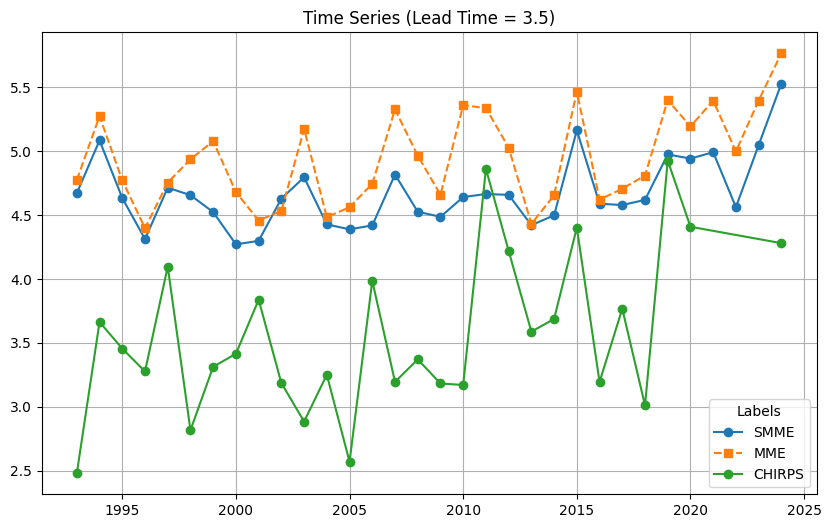

In [13]:
plt.figure(figsize = (10,6))

# -- SMME
plt.plot(SMME_lead3['realization_year'], SMME_lead3['predicted_precip'], marker = 'o', label = 'SMME')

# -- MME
plt.plot(MME_lead3['realization_year'], MME_lead3['predicted_precip'], marker = 's', linestyle = '--', label = 'MME')

# -- CHIRPS
plt.plot(chirps_SON['realization_year'], chirps_SON['precip'], marker = 'o', label = 'CHIRPS')

plt.title('Time Series (Lead Time = 3.5)')
plt.legend(title = 'Labels')
plt.grid(True)
plt.show()